In [8]:
# histogram of oriented gradients / hog
from google.colab import drive
import os
import cv2
import numpy as np
from skimage.feature import hog
from sklearn.model_selection import train_test_split
import time

# google drive
drive.mount('/content/drive')

# path dataset
path_runcing = '/content/drive/MyDrive/sukulen_cleaned/daun_runcing'
path_bulat = '/content/drive/MyDrive/sukulen_cleaned/daun_bulat'

data_features = []
labels = []

# function untuk membaca gambar dan dkstraksi hog
def extract_hog_features(folder_path, label):
    for filename in os.listdir(folder_path):
        if filename.endswith(('.jpg', '.jpeg', '.png')):
            img_path = os.path.join(folder_path, filename)
            img = cv2.imread(img_path)

            if img is not None:
                # standarisasi ukuran dan konversi ke grayscale
                img_resized = cv2.resize(img, (224, 224))
                img_gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)

                # ekstraksi fitur hog
                features = hog(img_gray, orientations=9, pixels_per_cell=(32, 32),
                               cells_per_block=(2, 2), block_norm='L2-Hys', transform_sqrt=True)

                data_features.append(features)
                labels.append(label)

# proses ekstraksi (0 untuk Runcing, 1 untuk Bulat)
print("Sedang mengekstrak fitur HOG....")
extract_hog_features(path_runcing, 0)
extract_hog_features(path_bulat, 1)

# konversi ke NumPy Array
X = np.array(data_features)
y = np.array(labels)

# pembagian 80:20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Total data latih: {X_train.shape[0]}, Total data uji: {X_test.shape[0]}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Sedang mengekstrak fitur HOG... Mohon tunggu.
Ekstraksi selesai! Total data latih: 320, Total data uji: 80


In [9]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import pandas as pd

# list untuk menyimpan hasil
hasil_percobaan = []

# 3 Skenario Parameter
# skenario = [
#     {"percobaan": 1, "kernel": 'linear', "C": 0.1, "gamma": 'scale', "tol": 1e-3, "max_iter": -1, "df_shape": 'ovo'},
#     {"percobaan": 2, "kernel": 'rbf', "C": 1.0, "gamma": 'scale', "tol": 1e-3, "max_iter": -1, "df_shape": 'ovo'},
#     {"percobaan": 3, "kernel": 'rbf', "C": 10.0, "gamma": 'scale', "tol": 1e-3, "max_iter": -1, "df_shape": 'ovo'}
# ]
skenario = [
    {"percobaan": 1, "kernel": 'linear', "C": 0.05, "gamma": 'scale', "tol": 1e-3, "max_iter": -1, "df_shape": 'ovo'},
    {"percobaan": 2, "kernel": 'linear', "C": 0.1, "gamma": 'scale', "tol": 1e-3, "max_iter": -1, "df_shape": 'ovo'},
    {"percobaan": 3, "kernel": 'rbf', "C": 0.5, "gamma": 'scale', "tol": 1e-3, "max_iter": -1, "df_shape": 'ovo'}
]

model_terbaik = None
akurasi_terbaik = 0

print("Mulai proses training 3 percobaan...\n")

for s in skenario:
    start_time = time.time()

    # model svm
    svm_model = SVC(kernel=s['kernel'], C=s['C'], gamma=s['gamma'],
                    tol=s['tol'], max_iter=s['max_iter'], decision_function_shape=s['df_shape'], random_state=42)

    # training
    svm_model.fit(X_train, y_train)

    # prediksi dan evaluasi
    y_pred = svm_model.predict(X_test)
    akurasi = accuracy_score(y_test, y_pred)
    error_rate = 1.0 - akurasi # Sebagai pengganti 'Loss' pada ML Tradisional

    waktu = time.time() - start_time

    # menyimpan hasil
    hasil_percobaan.append([s['percobaan'], s['kernel'], s['C'], s['gamma'], s['df_shape'], f"{akurasi*100:.2f}%", f"{error_rate:.4f}"])

    # menyimpan model terbaik untuk evaluasi selanjutnya
    if akurasi > akurasi_terbaik:
        akurasi_terbaik = akurasi
        model_terbaik = svm_model

# tabel hasil
df_hasil = pd.DataFrame(hasil_percobaan, columns=['Percobaan', 'Kernel', 'Parameter C', 'Gamma', 'Strategi Multi-class', 'Akurasi', 'Error Rate (Loss)'])
display(df_hasil)

Mulai proses training 3 percobaan...



,Percobaan,Kernel,Parameter C,Gamma,Strategi Multi-class,Akurasi,Error Rate (Loss)
0,1,linear,0.05,scale,ovo,68.75%,0.3125
1,2,linear,0.10,scale,ovo,72.50%,0.2750
2,3,rbf,0.50,scale,ovo,70.00%,0.3000


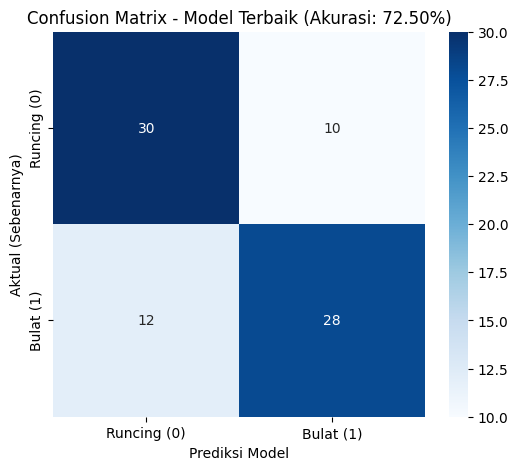


--- Metrik Evaluasi Model Terbaik ---
                  precision    recall  f1-score   support

Daun Runcing (0)       0.71      0.75      0.73        40
  Daun Bulat (1)       0.74      0.70      0.72        40

        accuracy                           0.72        80
       macro avg       0.73      0.72      0.72        80
    weighted avg       0.73      0.72      0.72        80



In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# prediksi menggunakan model terbaik
y_pred_best = model_terbaik.predict(X_test)

# menghitung confusion matrix
cm = confusion_matrix(y_test, y_pred_best)

# visualizationnnnnnn
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Runcing (0)', 'Bulat (1)'], yticklabels=['Runcing (0)', 'Bulat (1)'])
plt.title(f'Confusion Matrix - Model Terbaik (Akurasi: {akurasi_terbaik*100:.2f}%)')
plt.xlabel('Prediksi Model')
plt.ylabel('Aktual')
plt.show()

# Precision, Recall, F1-Score
print("\n--- Metrik Evaluasi Model Terbaik ---")
print(classification_report(y_test, y_pred_best, target_names=['Daun Runcing (0)', 'Daun Bulat (1)']))

In [12]:
from sklearn.metrics import accuracy_score

# 1. Prediksi dan hitung akurasi untuk Data Latih (Training)
y_pred_train = model_terbaik.predict(X_train)
akurasi_train = accuracy_score(y_train, y_pred_train)

# 2. Prediksi dan hitung akurasi untuk Data Uji (Testing)
y_pred_test = model_terbaik.predict(X_test)
akurasi_test = accuracy_score(y_test, y_pred_test)

# 3. Tampilkan Hasil
print("Pengecekan Overfitting")
print(f"Akurasi Data Latih (Training) : {akurasi_train*100:.2f}%")
print(f"Akurasi Data Uji (Testing)    : {akurasi_test*100:.2f}%")

# 4. Hitung selisih untuk menarik kesimpulan
selisih = abs(akurasi_train - akurasi_test) * 100

print(f"Pengecekan Overfitting")
print(f"Akurasi Data Latih (Training) : {akurasi_train*100:.2f}%")
print(f"Akurasi Data Uji (Testing)    : {akurasi_test*100:.2f}%")
print(f"Selisih Akurasi               : {selisih:.2f}%\n")

if selisih > 15.0:
    print("Kesimpulan: Model terindikasi OVERFITTING (selisih lebih dari 15%).")
elif selisih < 3.0 and akurasi_test < 60.0:
    print("Kesimpulan: Model terindikasi UNDERFITTING (akurasi terlalu rendah).")
else:
    print("Kesimpulan: Model berada pada batas AMAN (Good Fit). Performa stabil.")

--- Pengecekan Overfitting (Model Terbaik) ---
Akurasi Data Latih (Training) : 83.75%
Akurasi Data Uji (Testing)    : 72.50%
--- Pengecekan Overfitting ---
Akurasi Data Latih (Training) : 83.75%
Akurasi Data Uji (Testing)    : 72.50%
Selisih Akurasi               : 11.25%

Kesimpulan: Model berada pada batas AMAN (Good Fit). Performa stabil.
